In [44]:
import numpy as np
import pandas as pd

import sys
sys.path.insert(0, '..')
from utils.utils import *

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches

import seaborn as sns
import random

from scipy.optimize import leastsq
from scipy.stats import mannwhitneyu
import scipy.stats as stats

from matplotlib.ticker import FormatStrFormatter

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
np.random.seed(1)
random.seed(42)

qpcr_path = '../measurement_data/RT-qPCR-TNFa.xls'  # Update this path as needed
simoa_data= '../measurement_data/preliminary_simoa_data_081223.xlsx'
figures_path ='../paper_and_outputs/figures/'
extended_data_path = '../paper_and_outputs/tables/extended_data_tables.xlsx'


In [45]:
#uploaded = files.upload()


In [46]:
rawdata = pd.read_excel(qpcr_path,sheet_name="Amplification Data", skiprows=range(0, 32))
df = rawdata
df.columns = [c.replace(' ', '_') for c in df.columns]

results = pd.read_excel(qpcr_path,sheet_name="Results", skiprows=range(0, 32))
df = rawdata.merge(results[['Well','Sample Name']],how='left')
df.columns = [c.replace(' ', '_') for c in df.columns]
df_qpcr=df.copy()
df_qpcr 

,Well,Cycle,Target_Name,Rn,Delta_Rn,Sample_Name
0,1,1,TNF,0.299740,-0.040524,SW1
1,1,2,TNF,0.308211,-0.038075,SW1
2,1,3,TNF,0.323058,-0.029251,SW1
3,1,4,TNF,0.334739,-0.023592,SW1
4,1,5,TNF,0.347930,-0.016423,SW1
...,...,...,...,...,...,...
3835,96,36,NaN,NaN,NaN,NaN
3836,96,37,NaN,NaN,NaN,NaN
3837,96,38,NaN,NaN,NaN,NaN
3838,96,39,NaN,NaN,NaN,NaN


In [47]:
df_qpcr_tnf = df[df['Target_Name'].str.contains('TNF',na=False)]
df_qpcr_gap  = df[df['Target_Name'].str.contains('GAP',na=False)]
df_qpcr_tnf['Replicate_Num'] = df_qpcr_tnf['Well']%12 # TNFa is in the top 3 rows of the 96 well plate, with each row being 1 replicate
df_qpcr_gap['Replicate_Num'] = df_qpcr_gap['Well']%12-3 # GAPDH is in the next 3 rows

/var/folders/6w/fbmvs0s92sjf4q_9pttw7kxr0000gp/T/ipykernel_84258/2561137135.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_qpcr_tnf['Replicate_Num'] = df_qpcr_tnf['Well']%12 # TNFa is in the top 3 rows of the 96 well plate, with each row being 1 replicate
/var/folders/6w/fbmvs0s92sjf4q_9pttw7kxr0000gp/T/ipykernel_84258/2561137135.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_qpcr_gap['Replicate_Num'] = df_qpcr_gap['Well']%12-3 # GAPDH is in the next 3 rows


/var/folders/6w/fbmvs0s92sjf4q_9pttw7kxr0000gp/T/ipykernel_84258/3515486744.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_qpcr_tnf['delta_rn_epsilon']=df_qpcr_tnf['Delta_Rn']+eps


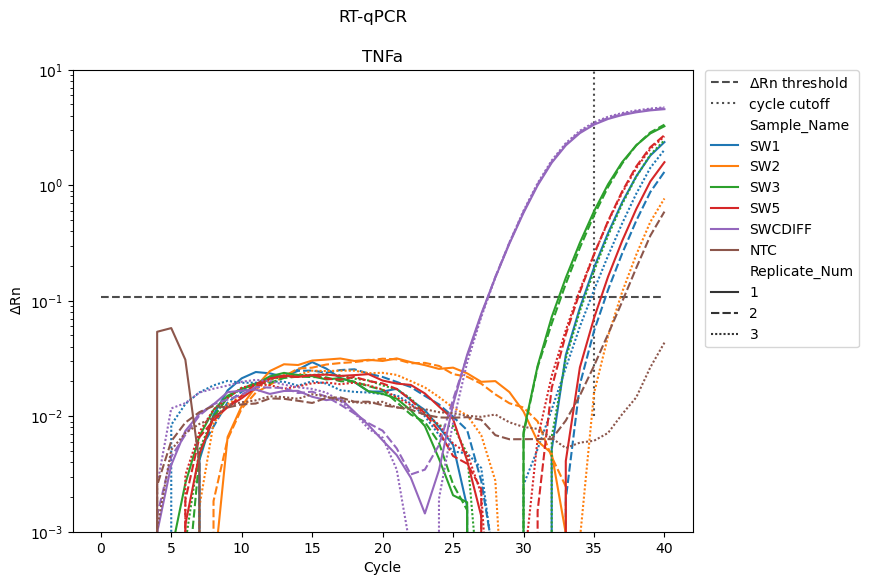

In [48]:
eps=.01
df_qpcr_tnf['delta_rn_epsilon']=df_qpcr_tnf['Delta_Rn']+eps

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
fig.suptitle('RT-qPCR')
ax.plot([0, 40],[0.097+eps, 0.097+eps],'--',c='.3',label=r'$\Delta$Rn threshold')
ax.plot([35, 35],[1e-2, 1e1],':',c='.3', label='cycle cutoff')
sns.lineplot(data=df_qpcr_tnf,x='Cycle',y='delta_rn_epsilon',hue='Sample_Name',style='Replicate_Num',ax=ax)
ax.set_title('TNFa')

ax.set_yscale('log')
ax.set_ylabel(r'$\Delta$Rn')
ax.set_ylim(1e-3,10)
h=plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.show()

In [49]:
df = results
df.columns = [c.replace(' ', '_') for c in df.columns]
df_qpcr_tnf_ct=df[df['Target_Name']=='TNF']
df_qpcr_tnf_ct['EQ.Ct_temp'] = df_qpcr_tnf_ct['EQ.Ct'].replace('Undetermined',40)
df_qpcr_tnf_ct['EQ.Ct'] = df_qpcr_tnf_ct['EQ.Ct'].replace('Undetermined',42.5)

/var/folders/6w/fbmvs0s92sjf4q_9pttw7kxr0000gp/T/ipykernel_84258/4289541808.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_qpcr_tnf_ct['EQ.Ct_temp'] = df_qpcr_tnf_ct['EQ.Ct'].replace('Undetermined',40)
/var/folders/6w/fbmvs0s92sjf4q_9pttw7kxr0000gp/T/ipykernel_84258/4289541808.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_qpcr_tnf_ct['EQ.Ct_temp'] = df_qpcr_tnf_ct['EQ.Ct'].replace('Undetermined',40)
/var/folders/6w/fbmvs0s92sjf4q_9pttw7kxr0000gp/T/ipykernel_84258/4289541808.py:5: FutureWarning: Downcas

In [50]:
# calculate mean and standard deviation of Ct values for each sample
df_summary = df_qpcr_tnf_ct.groupby('Sample_Name')['EQ.Ct_temp'].agg(['mean', 'std']).reset_index()
df_summary.columns = ['Sample_Name', 'Ct_mean', 'Ct_std']

In [51]:
# mean of ntc -1.645* std of ntc - 1.645 * std of SW1  using df_summary
ntc_mean = df_summary[df_summary['Sample_Name']=='NTC']['Ct_mean'].values[0]
ntc_std = df_summary[df_summary['Sample_Name']=='NTC']['Ct_std'].values[0]
sw1_std = df_summary[df_summary['Sample_Name']=='SW1']['Ct_std'].values[0]
ct_lod = ntc_mean - 1.645*ntc_std - 1.645*sw1_std
print(df_summary)
print('Ct LOD:', ct_lod)


  Sample_Name    Ct_mean    Ct_std
0         NTC  39.029549  1.680871
1         SW1  34.989426  0.782485
2         SW2  38.964036  1.794342
3         SW3  33.200976  1.026321
4         SW5  34.418172  0.960823
5     SWCDIFF  27.509166  0.021712
Ct LOD: 34.97732783360934


/var/folders/6w/fbmvs0s92sjf4q_9pttw7kxr0000gp/T/ipykernel_84258/411471384.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Conv4', 'Conv5', 'Conv6', 'Conv7', 'Cdiff1', 'Control'], rotation=90)
/var/folders/6w/fbmvs0s92sjf4q_9pttw7kxr0000gp/T/ipykernel_84258/411471384.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['']*6)


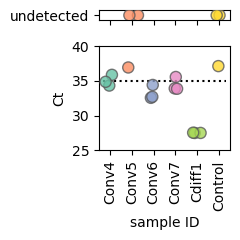

In [ ]:
h=2.5

fig, axes = plt.subplots(2, 1, figsize=(h, h), gridspec_kw={'height_ratios': [.3, 3]})


axes[1].plot([-.3, 5.3], [ct_lod, ct_lod], 'k:')
fg1=sns.stripplot(ax=axes[1],data=df_qpcr_tnf_ct,x='Sample_Name',y='EQ.Ct', hue='Sample_Name', size=8, linewidth=1, alpha=0.8 , jitter=.2,
                   palette=sns.color_palette('Set2', n_colors=6))
ax=axes[1]
ax.set_ylim([25,40])
#axes[1].get_legend().remove()

axes[1].set_xlabel('sample ID')
axes[1].set_ylabel('Ct')
axes[1].set_xticklabels(['Conv4', 'Conv5', 'Conv6', 'Conv7', 'Cdiff1', 'Control'], rotation=90)

fg2=sns.stripplot(ax=axes[0],data=df_qpcr_tnf_ct,x='Sample_Name',y='EQ.Ct', hue='Sample_Name', size=8, linewidth=1, jitter=.3, alpha=0.8 ,
                  palette=sns.color_palette('Set2', n_colors=6))
ax=axes[0]
#axes[0].get_legend().remove()
ax.set_ylim([42,43])
ax.set_yticks([42.5])
ax.set_xticklabels(['']*6)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_yticklabels(['undetected'])

plt.tight_layout()

In [53]:

rawdata = pd.read_excel(simoa_data,sheet_name="raw data")
rawdata.columns = [c.replace(' ', '_') for c in rawdata.columns]
df=rawdata
df['sample'] = df.Sample_Barcode.apply(lambda x: x[-1])
#df['mouse_type'] = np.where(df['sample']=='1' | df['sample']=='2' | df['sample']=='3','GF','Conv')
df["dilution"] = df["Sample_Barcode"].str.extract("(1-2|1-4|1-8)")[0]
df["spin"] = df["Sample_Barcode"].str.extract("(high|low)")[0]

filter = df['Sample_Barcode'].str.contains('(Cal|spike|cont)')
filtered_df = df[~filter]

_tmp1=filtered_df['sample']=='1'
_tmp2=filtered_df['sample']=='2'
_tmp3=filtered_df['sample']=='3'

_tmp4=_tmp1 | _tmp2 | _tmp3

filtered_df['mouse_type'] = np.where(_tmp4,'GF','Conv')

/var/folders/6w/fbmvs0s92sjf4q_9pttw7kxr0000gp/T/ipykernel_84258/3215971251.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  filter = df['Sample_Barcode'].str.contains('(Cal|spike|cont)')
/var/folders/6w/fbmvs0s92sjf4q_9pttw7kxr0000gp/T/ipykernel_84258/3215971251.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['mouse_type'] = np.where(_tmp4,'GF','Conv')


/var/folders/6w/fbmvs0s92sjf4q_9pttw7kxr0000gp/T/ipykernel_84258/1513943138.py:67: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['mapped_conc'] = filtered_df['Replicate_AEB'].apply(map_aeb_conc)
/var/folders/6w/fbmvs0s92sjf4q_9pttw7kxr0000gp/T/ipykernel_84258/1513943138.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['dilution_int'] = filtered_df.dilution.apply(lambda x: x[-1]).astype('int')
/var/folders/6w/fbmvs0s92sjf4q_9pttw7kxr0000gp/T/ipykernel_84258/1513943138.py:71: Setti

[(100, 20000)]

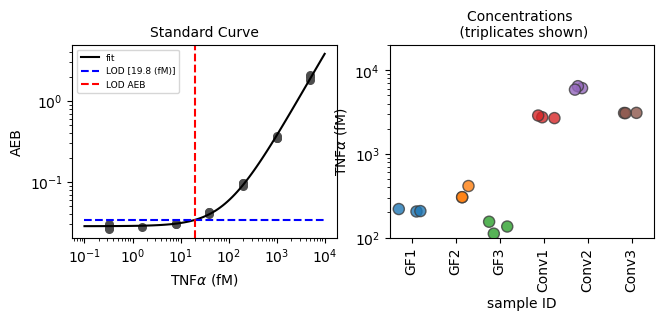

In [54]:
### separating calibration and data

# replace logistic4 with logistic5
onlyraw = rawdata[rawdata['Replicate_AEB'].notnull()]
cal = onlyraw[onlyraw.Sample_Barcode.str.startswith('Calibrator')]
data = onlyraw[~onlyraw.Sample_Barcode.str.startswith('Calibrator')]



def logistic5(x, A, B, C, D, E):
    """5PL logistic equation."""
    return D + (A - D) / (1.0 + (x / C)**B)**E

def residuals(p, y, x):
    """Deviations of data from fitted 5PL curve"""
    A,B,C,D,E = p
    err = y-logistic5(x, A, B, C, D, E)
    return err

def peval(x, p):
    """Evaluated value at x with current parameters."""
    A,B,C,D,E = p
    return logistic5(x, A, B, C, D, E)

def pinverse(y, p):
    """Inverted value at y for logistic5 curve"""
    A,B,C,D,E = p
    return C*(((A-D)/(y-D))**(1/E)-1)**(1/B)


# Make up some data for fitting and add noise
# In practice, y_meas would be read in from a file
x = np.logspace(-1, 4, num=100)

temp = cal
yp,xp = temp['Replicate_AEB'],temp['Replicate_Conc.']

# Initial guess for parameters
A = np.min(yp)  # Bottom asymptote
D = np.max(yp) # Top asymptote  
C = (A+D)/2  # Inflection point (middle concentration)
B = 1.0           # Hill slope
E = 1.0  
p0 = [A, B, C, D, E]


sigma_data = np.abs(yp)  # Example: Poisson-like noise model
params, _ = curve_fit(linear_5pl, xp, yp, p0=p0, maxfev=100000, sigma=sigma_data, absolute_sigma=False)
plsq = params


### Plotting data points
#### setting up
low = data[data.Sample_Barcode.str.startswith('low')]
high = data[data.Sample_Barcode.str.startswith('high')]
control = data[data.Sample_Barcode=='contro']
control_spike = data[data.Sample_Barcode=='control+spike']
low_spike = data[data.Sample_Barcode.str.startswith('spikein-1')]
high_spike = data[data.Sample_Barcode.str.startswith('spikein-high')]
# Function to invert the Cal curve to compute conc from AEB, Linear interpolation.
temp2 = cal#.groupby('Sample_Barcode').mean()
xp1,yp1 = temp['Replicate_AEB'],temp['Replicate_Conc.']
map_aeb_conc = lambda x: np.interp(x,xp1,yp1)
#### Concentration Plots

# Now adding a row which maps AEB to concentration using Cal curve
filtered_df['mapped_conc'] = filtered_df['Replicate_AEB'].apply(map_aeb_conc)

# multiplying concentrations by dilution factor for true comparison
filtered_df['dilution_int'] = filtered_df.dilution.apply(lambda x: x[-1]).astype('int')
filtered_df['scaled_conc'] = filtered_df['mapped_conc']*filtered_df['dilution_int']


h=2.5
s=3

fig, axes = plt.subplots(1, 2, figsize=(h*s, h))
LOD=0.034 # computed in raw data file raw data-081223.xlsx
LOD_AEB=pinverse(LOD,params)

# Plot results
axes[0].plot(x,peval(x,params),'k')
axes[0].plot([1e-1,1e4],[LOD,LOD],'b--')
axes[0].axvline(x=LOD_AEB, color='r', linestyle='--', label='LOD')
axes[0].scatter(xp,yp,s=30,color='.3')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('TNF' r'$\alpha$' ' (fM)')
axes[0].set_ylabel('AEB')
# legend should use actual lod value LOD_AEB with one one value after decimal 16.2
axes[0].legend(['fit',  f'LOD [{LOD_AEB:.1f} (fM)]','LOD AEB'], fontsize=6.5)
axes[0].set_title('Standard Curve', fontsize=10)


df1=filtered_df[filtered_df['spin']=='low']
df2=df1[df1['dilution']=='1-2']
fg=sns.stripplot(ax=axes[1],data=df2,x='sample',y='scaled_conc', hue='sample',size=8, linewidth=1,legend=False, alpha=0.8, jitter =0.3)
#fg=sns.boxplot(ax=axes[1],data=df2,x='sample',y='scaled_conc',width=.6, palette="vlag")
axes[1].set_yscale('log')
axes[1].set_ylabel('TNF' r'$\alpha$' ' (fM)')
axes[1].set_xlabel('sample ID')
axes[1].set_title('Concentrations \n (triplicates shown)', fontsize=10)
axes[1].set_xticklabels(['GF1', 'GF2', 'GF3', 'Conv1', 'Conv2', 'Conv3'], rotation=90)

fg.set(ylim=(100, 20000))

In [55]:
params

array([2.84701691e-02, 1.05557424e+00, 1.11240911e+05, 4.17333510e+03,
       1.20598887e-02])

/var/folders/6w/fbmvs0s92sjf4q_9pttw7kxr0000gp/T/ipykernel_84258/3689555139.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Conv4', 'Conv5', 'Conv6', 'Conv7', 'Cdiff1', 'Blank'], rotation=90)
/var/folders/6w/fbmvs0s92sjf4q_9pttw7kxr0000gp/T/ipykernel_84258/3689555139.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fg1=sns.stripplot(ax=ax,
/var/folders/6w/fbmvs0s92sjf4q_9pttw7kxr0000gp/T/ipykernel_84258/3689555139.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fg=sns.stripplot(ax=ax,
/var/folders/6w/fbmvs0s92sjf4q_9pttw7kxr0000gp/T/ipykernel_84258/3689555139.py:84: UserWarning: set_ticklabels() 

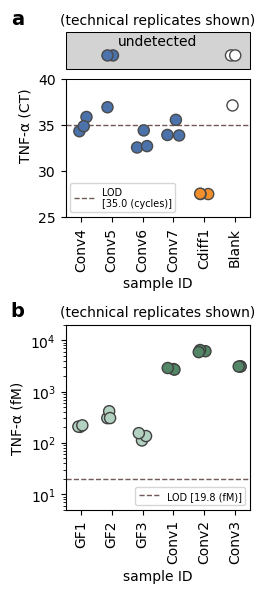

In [56]:
random.seed(42)
np.random.seed(42)
fig, axes = plt.subplots(2, 1, figsize=(3, 6), layout="constrained")


ax=axes[0]
ax.set_ylim([25,45])
#axes[1].get_legend().remove()

lod="#715959"
#not_detected="#cdc3bc"
conv_alt="#4b72aa"#'#7b848f'
#cdiff='#F28E2B'
#blank='white'
#gf="#b0cae2"

conv="#528667"#'#7b848f'
cdiff='#F28E2B'
blank='white'
gf="#b3d1c1"
colors1 = [conv_alt,conv_alt,conv_alt,conv_alt, cdiff,blank]
colors2=[gf,gf,gf,conv,conv,conv]

ax.set_xlabel('sample ID')
ax.set_ylabel('TNF-\u03B1 (CT)')
ax.set_xticklabels(['Conv4', 'Conv5', 'Conv6', 'Conv7', 'Cdiff1', 'Blank'], rotation=90)
ax.set_yticks([25,30,35,40])
ax.set_box_aspect(1)
ax.set_title('(technical replicates shown)', fontsize=10)

#ax.axhline(y=41, color='k', linestyle='-',linewidth=0.75)
ax.axhline(y=40, color='k', linestyle='-',linewidth=0.75)
ax.axhline(y=ct_lod, color=lod, linestyle='--',linewidth=1, label=f'LOD\n[{ct_lod:.1f} (cycles)]')

ax.spines['left'].set_bounds(25, 40)
ax.spines['right'].set_bounds(25, 40)
ax.spines['top'].set_visible(False)

rect1 = patches.Rectangle((-0.5, 41), 6, 4, linewidth=0.75, edgecolor='black', facecolor='lightgray')
ax.add_patch(rect1)

ax.text(0.5, 0.95, 'undetected', horizontalalignment='center',
     verticalalignment='center', transform=ax.transAxes)

ax.set_box_aspect(1)

for artist in ax.get_children():
    artist.set_clip_on(False)


fg1=sns.stripplot(ax=ax,
                  data=df_qpcr_tnf_ct,
                  x='Sample_Name',
                  y='EQ.Ct',
                  #hue='Sample_Name',
                  size=8,
                  linewidth=1,
                  jitter=.2,
                  alpha=1,
                  palette=colors1)#sns.color_palette('Set2', n_colors=6))

# add legend but just for ct_lod
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=7, loc='lower left')


ax=axes[1]
fg=sns.stripplot(ax=ax,
                 data=df2,
                 x='sample',
                 y='scaled_conc', 
                 #hue='sample',
                 size=8, 
                 linewidth=1,
                 legend=False, 
                 alpha=1, 
                 jitter =0.2, 
                 palette=colors2)#sns.color_palette('Set2', n_colors=6))
ax.set_yscale('log')
ax.set_ylabel('TNF-\u03B1 (fM)')
ax.set_xlabel('sample ID')
ax.set_title('(technical replicates shown)', fontsize=10)
ax.set_xticklabels(['GF1', 'GF2', 'GF3', 'Conv1', 'Conv2', 'Conv3'], rotation=90)
ax.axhline(y=LOD_AEB, color=lod, linestyle='--',linewidth=1, label=f'LOD [{LOD_AEB:.1f} (fM)]')
ax.set_ylim([5, 20000])
    
#only include lod in legend for second plot, place at bottom right 
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=7, loc='lower right')

ax.set_box_aspect(1)
plt.tight_layout()
# annotate with a, b added to each subplot
for i, ax in enumerate(axes):
    ax.annotate(f'{chr(97+i)}', xy=(0, 1), xycoords='axes fraction',
                xytext=(-30, 3), textcoords='offset points',
                ha='right', va='bottom', fontsize=14, fontweight='bold')


plt.savefig(figures_path+"tnfalpha_RTqPCR.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [14]:
LOD_AEB

np.float64(19.752240876400116)

In [15]:
df2

,Sample_Barcode,Assay,Plex,Location,Carrier_Barcode,Replicate_AEB,Mean_AEB,SD_AEB,CV_AEB,Replicate_Conc.,...,Dilution_Factor,Dilution_Description,Extended_Properties,sample,dilution,spin,mouse_type,mapped_conc,dilution_int,scaled_conc
32,low-1-2-1,sz_tnfa,CD9_488,Plate 1 - Well A3,P1,0.061777,NaN,NaN,NaN,107.486056,...,1,Neat,0002_DecodingIntensityStdDev_577F1:40.269;0002...,1,1-2,low,GF,102.625038,2,205.250076
33,low-1-2-1,sz_tnfa,CD9_488,Plate 1 - Well A3,P1,0.062153,NaN,NaN,NaN,108.635803,...,1,Neat,0002_DecodingIntensityStdDev_577F1:60.806;0002...,1,1-2,low,GF,103.697891,2,207.395782
34,low-1-2-1,sz_tnfa,CD9_488,Plate 1 - Well A3,P1,0.064266,NaN,NaN,NaN,115.084138,...,1,Neat,0002_DecodingIntensityStdDev_577F1:73.725;0002...,1,1-2,low,GF,109.725152,2,219.450303
35,low-1-2-1,sz_tnfa,CD9_488,Plate 1 - Well A3,P1,NaN,0.062732,0.001342,0.021387,NaN,...,1,Neat,NaN,1,1-2,low,GF,NaN,2,NaN
36,low-1-2-2,sz_tnfa,CD9_488,Plate 1 - Well B3,P1,0.079032,NaN,NaN,NaN,159.707328,...,1,Neat,0002_DecodingIntensityStdDev_577F1:81.624;0002...,2,1-2,low,GF,151.849341,2,303.698681
37,low-1-2-2,sz_tnfa,CD9_488,Plate 1 - Well B3,P1,0.090993,NaN,NaN,NaN,195.396858,...,1,Neat,0002_DecodingIntensityStdDev_577F1:89.497;0002...,2,1-2,low,GF,206.737439,2,413.474878
38,low-1-2-2,sz_tnfa,CD9_488,Plate 1 - Well B3,P1,0.079132,NaN,NaN,NaN,160.006314,...,1,Neat,0002_DecodingIntensityStdDev_577F1:83.940;0002...,2,1-2,low,GF,152.133748,2,304.267495
39,low-1-2-2,sz_tnfa,CD9_488,Plate 1 - Well B3,P1,NaN,0.083052,0.006877,0.082805,NaN,...,1,Neat,NaN,2,1-2,low,GF,NaN,2,NaN
40,low-1-2-3,sz_tnfa,CD9_488,Plate 1 - Well C3,P1,0.045337,NaN,NaN,NaN,56.499100,...,1,Neat,0002_DecodingIntensityStdDev_577F1:50.720;0002...,3,1-2,low,GF,55.725391,2,111.450783
41,low-1-2-3,sz_tnfa,CD9_488,Plate 1 - Well C3,P1,0.049579,NaN,NaN,NaN,69.815534,...,1,Neat,0002_DecodingIntensityStdDev_577F1:57.445;0002...,3,1-2,low,GF,67.826551,2,135.653101


In [ ]:
df_simoa=df2[['sample', 'scaled_conc']]
# replace 1,2,3,4,5,6 with #['GF1', 'GF2', 'GF3', 'Conv1', 'Conv2', 'Conv3']
df_simoa['sample'] = df_simoa['sample'].replace({'1':'GF1', '2':'GF2', '3':'GF3', '4':'Conv1', '5':'Conv2', '6':'Conv3'})
# remove missing values
df_simoa = df_simoa.dropna()
df_simoa

/var/folders/6w/fbmvs0s92sjf4q_9pttw7kxr0000gp/T/ipykernel_84258/349644424.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_simoa['sample'] = df_simoa['sample'].replace({'1':'GF1', '2':'GF2', '3':'GF3', '4':'Conv1', '5':'Conv2', '6':'Conv3'})


,sample,scaled_conc
32,GF1,205.250076
33,GF1,207.395782
34,GF1,219.450303
36,GF2,303.698681
37,GF2,413.474878
38,GF2,304.267495
40,GF3,111.450783
41,GF3,135.653101
42,GF3,154.751236
44,Conv1,2742.531692


In [17]:
df_qpcr=df_qpcr_tnf_ct[['Sample_Name', 'EQ.Ct']]
# replace 42.5 with 'undetected'
df_qpcr['EQ.Ct'] = df_qpcr['EQ.Ct'].replace(42.5, 'undetected')
# replace sample names with Conv4, Conv5, Conv6, Conv7, Cdiff1, Blank
df_qpcr['Sample_Name'] = df_qpcr['Sample_Name'].replace({'SW1':'Conv4', 'SW2':'Conv5', 'SW3':'Conv6', 'SW5':'Conv7', 'SWCDIFF':'Cdiff1', 'NTC':'Blank'})
df_qpcr

/var/folders/6w/fbmvs0s92sjf4q_9pttw7kxr0000gp/T/ipykernel_84258/1056010970.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_qpcr['EQ.Ct'] = df_qpcr['EQ.Ct'].replace(42.5, 'undetected')
/var/folders/6w/fbmvs0s92sjf4q_9pttw7kxr0000gp/T/ipykernel_84258/1056010970.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_qpcr['Sample_Name'] = df_qpcr['Sample_Name'].replace({'SW1':'Conv4', 'SW2':'Conv5', 'SW3':'Conv6', 'SW5':'Conv7', 'SWCDIFF':'Cdiff1', 'NTC':'Blank'})


,Sample_Name,EQ.Ct
0,Conv4,34.295189
1,Conv4,35.837353
2,Conv4,34.835735
6,Conv5,undetected
7,Conv5,undetected
8,Conv5,36.892109
12,Conv6,32.536442
13,Conv6,32.68346
14,Conv6,34.383026
18,Conv7,35.527214


In [18]:
# save CT values and concentrations to extended data tables
with pd.ExcelWriter(extended_data_path, mode='a', engine='openpyxl', if_sheet_exists='replace') as writer:
    df_simoa.to_excel(writer, sheet_name='tnfa_preliminary_simoa', index=False)
    df_qpcr.to_excel(writer, sheet_name='tnfa_RT_qPCR', index=False)